## Project 3 LiverPatient Predition

### Domain : Healthcare

### Project Overview:
#### This project predicts liver disease using the Indian Liver Patient Dataset (ILPD) containing 583 patient records.
#### Goal: Build and compare classification models to predict whether a patient has liver disease based on lab test values.
#### Dataset: 10 features, 583 records, binary classification.
#### Models Used: Logistic Regression, KNN, Decision Tree, Random Forest (Default + Tuned versions)
#### Best Model: Logistic Regression (Tuned) — F1=0.834, Recall=1.0

### Import required libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
df=pd.read_csv("Liver Patient.csv", encoding="latin-1")
df.head()

,Age,Gender,Total Bilirubin,Direct Bilirubin,Alkaline Phosphotase,Alamine aminotransferase,Aspartate Aminotransferase,Total Protiens,Albumin,Albumin and Globulin Ratio,Target
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


### Basic Checks

In [3]:
df.tail()

,Age,Gender,Total Bilirubin,Direct Bilirubin,Alkaline Phosphotase,Alamine aminotransferase,Aspartate Aminotransferase,Total Protiens,Albumin,Albumin and Globulin Ratio,Target
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1
582,38,Male,1.0,0.3,216,21,24,7.3,4.4,1.50,2


In [4]:
df.describe()

,Age,Total Bilirubin,Direct Bilirubin,Alkaline Phosphotase,Alamine aminotransferase,Aspartate Aminotransferase,Total Protiens,Albumin,Albumin and Globulin Ratio,Target
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total Bilirubin             583 non-null    float64
 3   Direct Bilirubin            583 non-null    float64
 4   Alkaline Phosphotase        583 non-null    int64  
 5   Alamine aminotransferase    583 non-null    int64  
 6   Aspartate Aminotransferase  583 non-null    int64  
 7   Total Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin and Globulin Ratio  579 non-null    float64
 10  Target                      583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [6]:
df.shape

(583, 11)

In [7]:
df.isnull()

,Age,Gender,Total Bilirubin,Direct Bilirubin,Alkaline Phosphotase,Alamine aminotransferase,Aspartate Aminotransferase,Total Protiens,Albumin,Albumin and Globulin Ratio,Target
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
578,False,False,False,False,False,False,False,False,False,False,False
579,False,False,False,False,False,False,False,False,False,False,False
580,False,False,False,False,False,False,False,False,False,False,False
581,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Age                           0
Gender                        0
Total Bilirubin               0
Direct Bilirubin              0
Alkaline Phosphotase          0
Alamine aminotransferase      0
Aspartate Aminotransferase    0
Total Protiens                0
Albumin                       0
Albumin and Globulin Ratio    4
Target                        0
dtype: int64

### Handling Missing values
#### Numeric column fill with median

In [9]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


In [10]:
df.isnull().sum()

Age                           0
Gender                        0
Total Bilirubin               0
Direct Bilirubin              0
Alkaline Phosphotase          0
Alamine aminotransferase      0
Aspartate Aminotransferase    0
Total Protiens                0
Albumin                       0
Albumin and Globulin Ratio    0
Target                        0
dtype: int64

In [11]:
df['Gender'].isnull().sum()

np.int64(0)

In [12]:
df.columns

Index(['Age', 'Gender', 'Total Bilirubin', 'Direct Bilirubin',
       'Alkaline Phosphotase', 'Alamine aminotransferase',
       'Aspartate Aminotransferase', 'Total Protiens', 'Albumin ',
       'Albumin and Globulin Ratio', 'Target'],
      dtype='object')

### Label Encoder

In [13]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  # Male=1, Female=0
df['Gender'].value_counts()

Gender
1    441
0    142
Name: count, dtype: int64

### Task 1 - Data analysis(EDA)

### Class Distribution univariate analysis

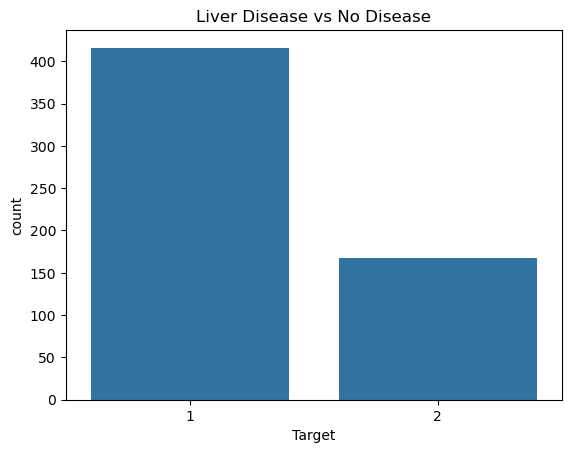

In [14]:
sns.countplot(x='Target', data=df)
plt.title("Liver Disease vs No Disease")
plt.show()

### Age Distribution Histogram

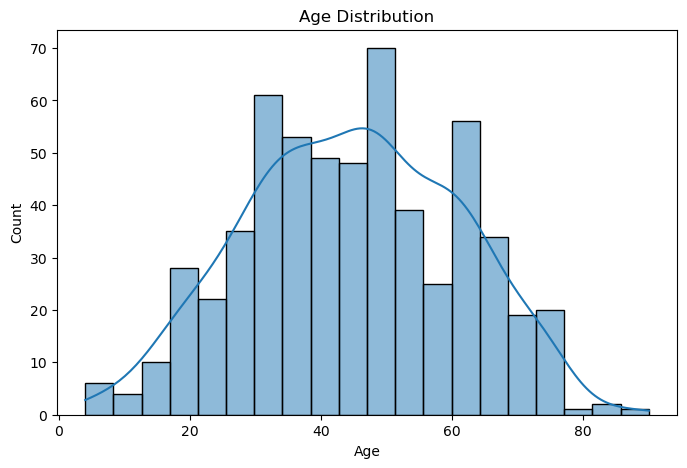

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

### Gender vs Disease

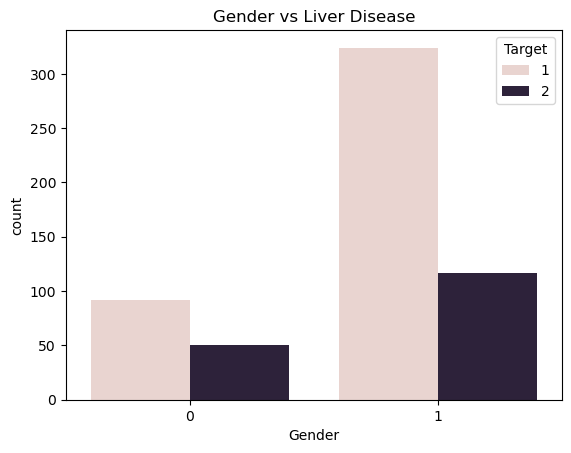

In [16]:
sns.countplot(x='Gender', hue='Target', data=df)
plt.title("Gender vs Liver Disease")
plt.show()

### Boxplots (Detect Outliers) Bivariate analysis

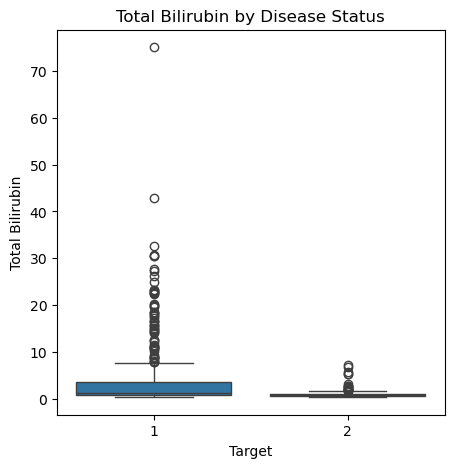

In [17]:
plt.figure(figsize=(5,5))
sns.boxplot(x='Target', y='Total Bilirubin', data=df)
plt.title("Total Bilirubin by Disease Status")
plt.show()

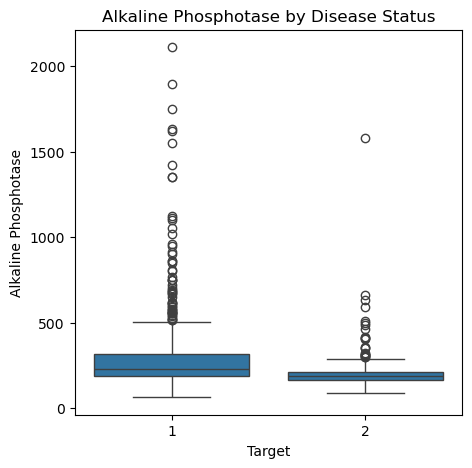

In [18]:
plt.figure(figsize=(5,5))
sns.boxplot(x='Target', y='Alkaline Phosphotase', data=df)
plt.title("Alkaline Phosphotase by Disease Status")
plt.show()

### PairPlot

<Figure size 1200x1200 with 0 Axes>

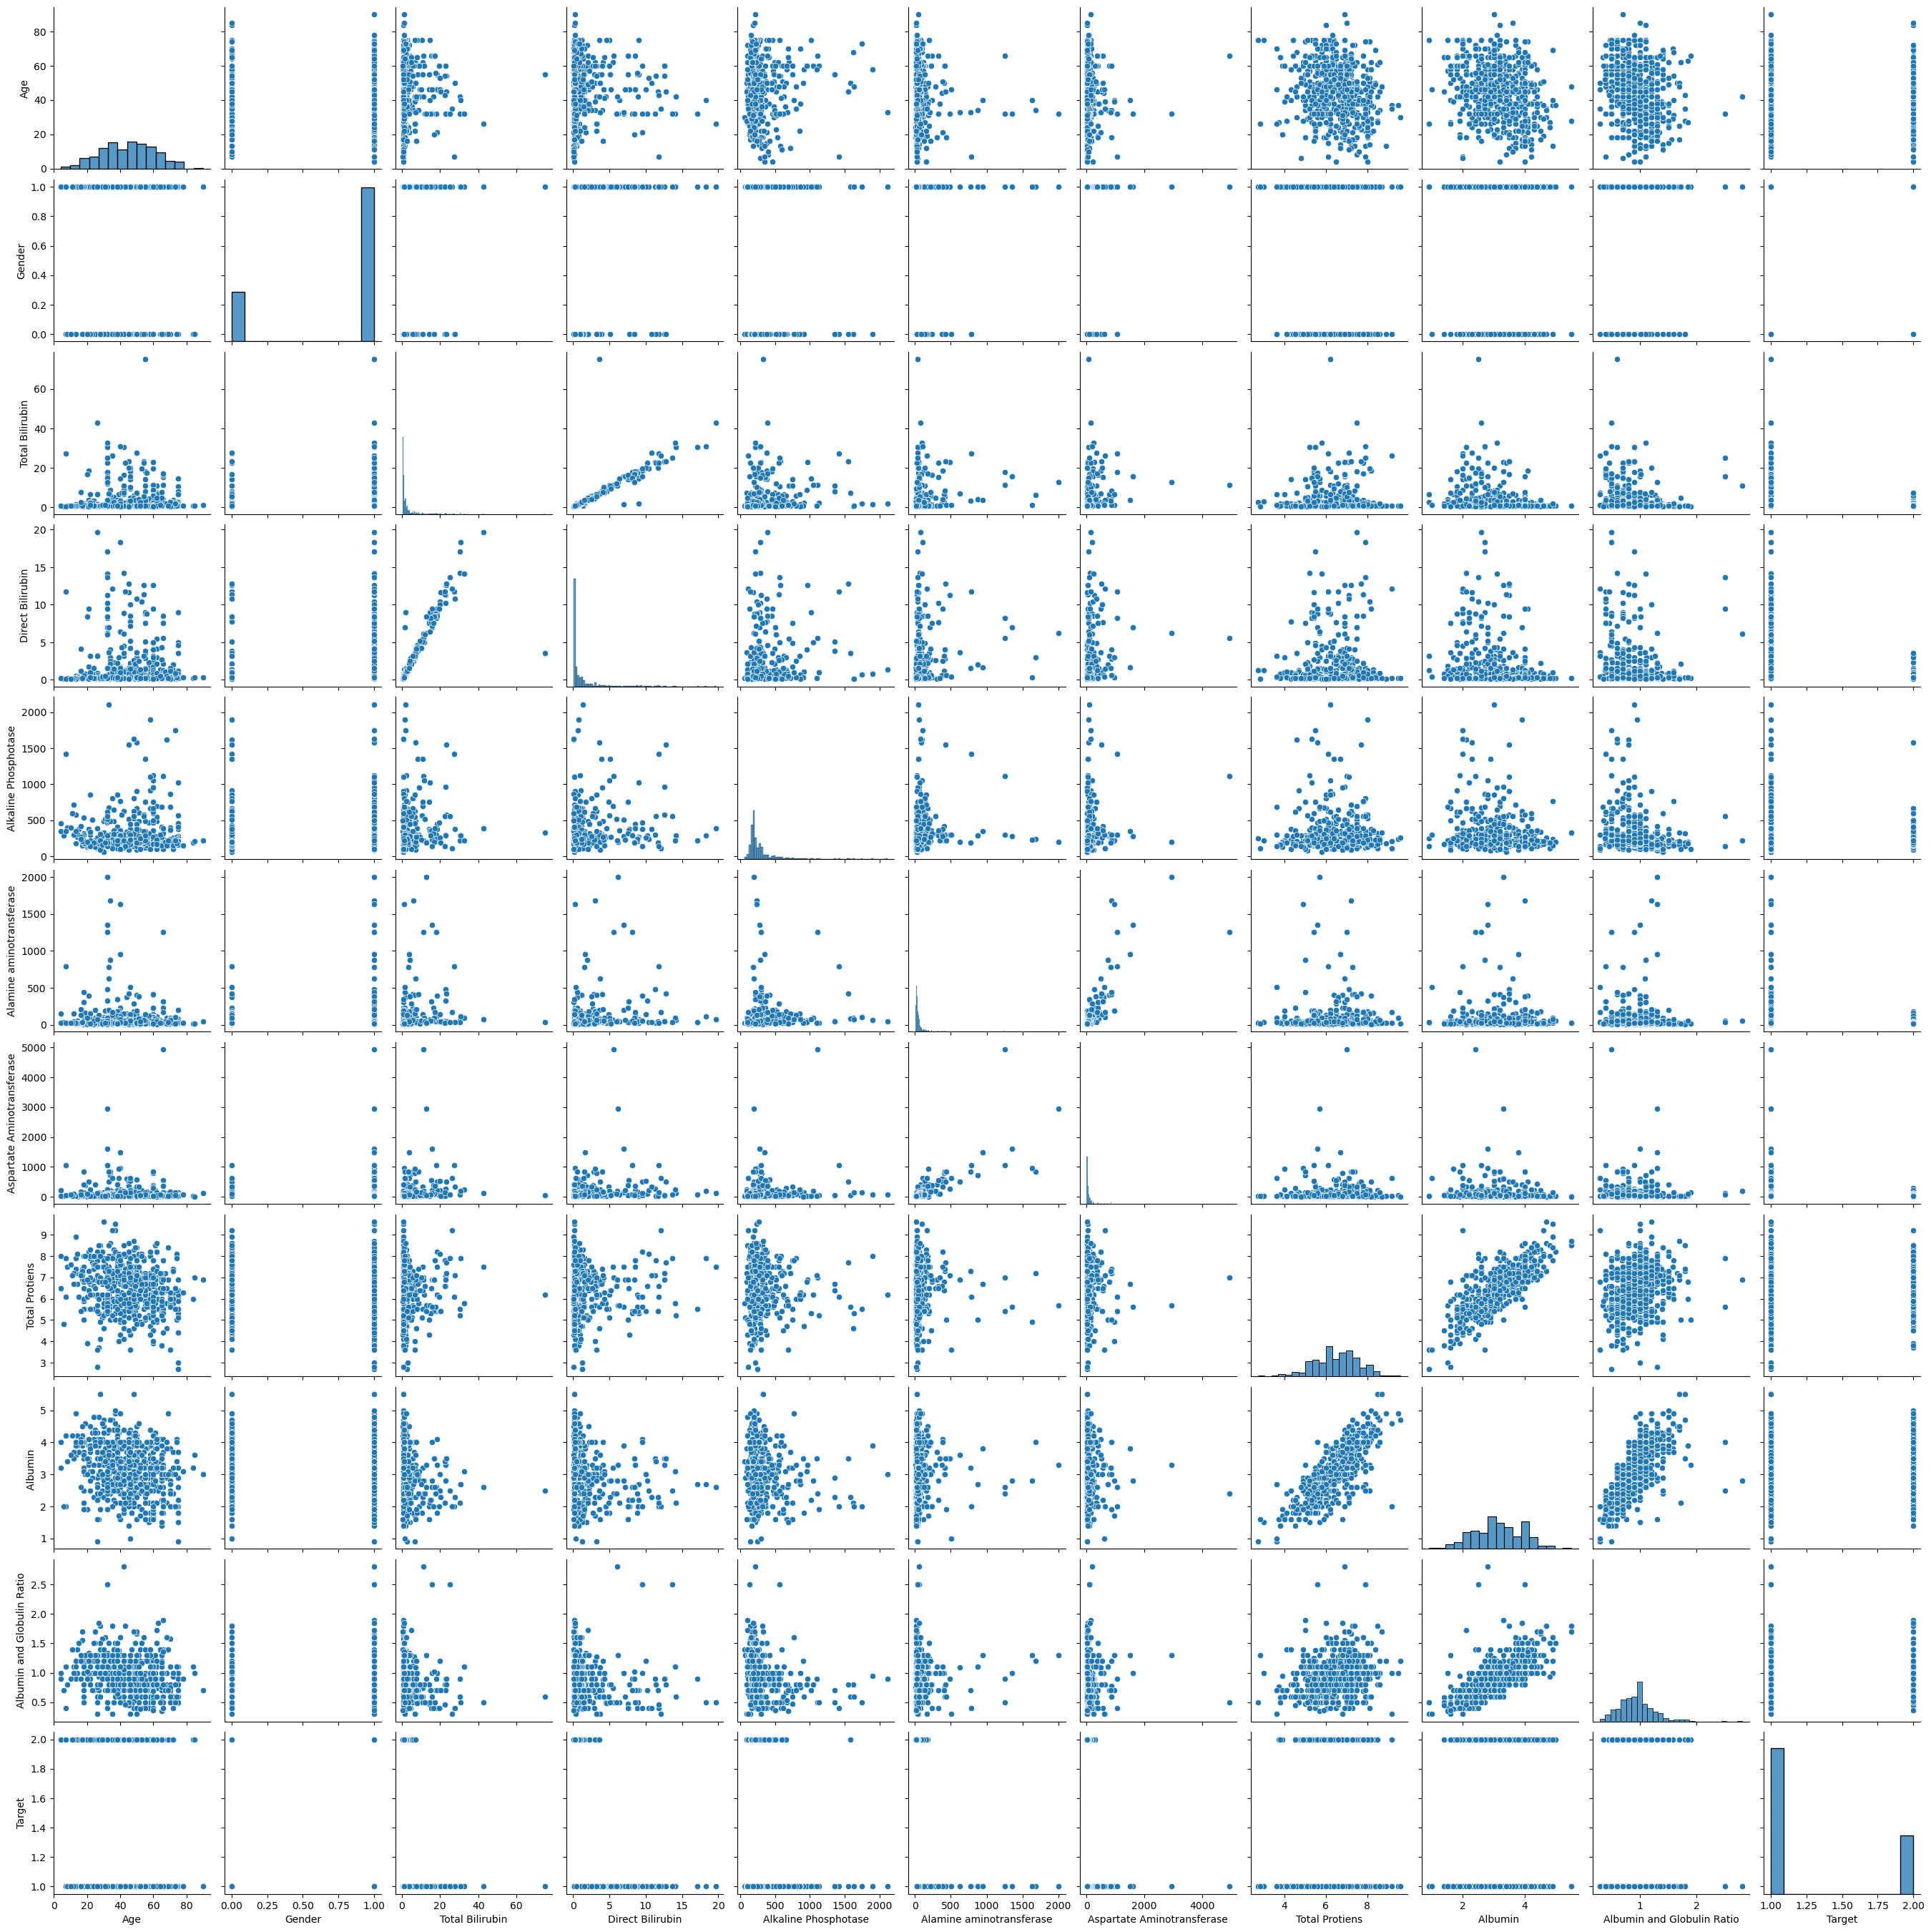

In [19]:
plt.figure(figsize=(12,12))
sns.pairplot(df)
plt.show()

### Distribution Plot of Important Lab Values

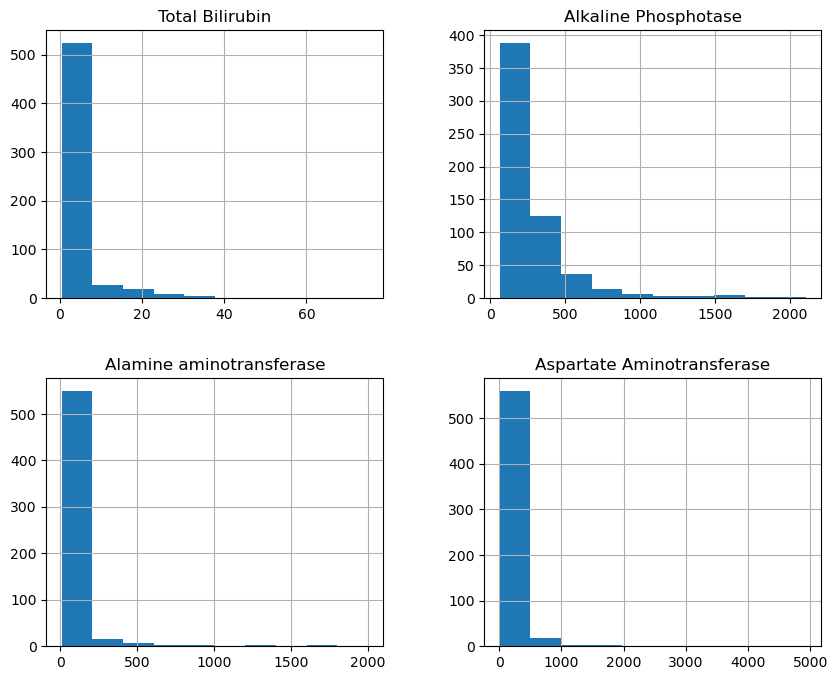

In [20]:
important_cols = [
    'Total Bilirubin',
    'Alkaline Phosphotase',
    'Alamine aminotransferase',
    'Aspartate Aminotransferase'
]

df[important_cols].hist(figsize=(10,8))
plt.show()

### Age Group Analysis

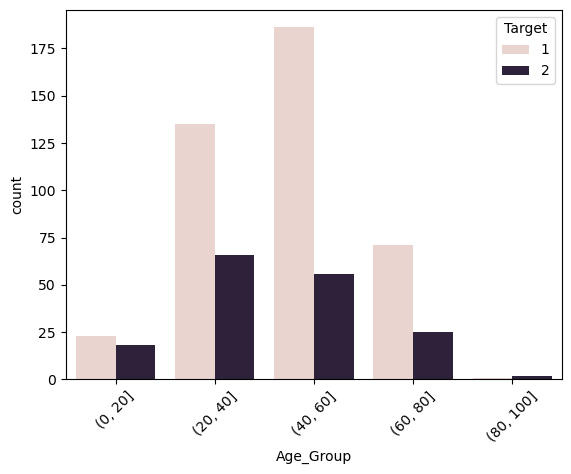

In [21]:
df['Age_Group'] = pd.cut(df['Age'], bins=[0,20,40,60,80,100])

sns.countplot(x='Age_Group', hue='Target', data=df)
plt.xticks(rotation=45)
plt.show()

### Albumin vs Bilirubin Scatter Plot

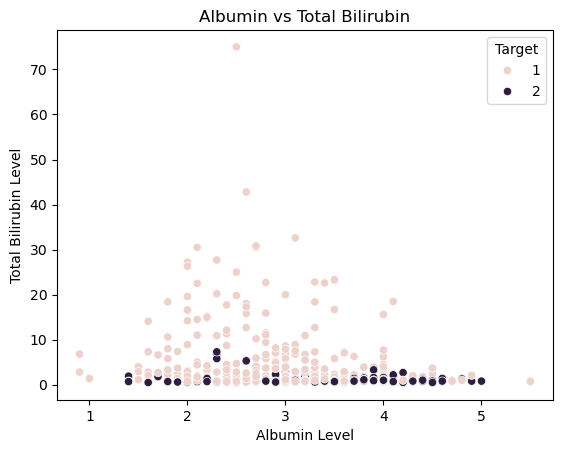

In [49]:
sns.scatterplot(x='Albumin ', y='Total Bilirubin', hue='Target', data=df)
plt.title("Albumin vs Total Bilirubin")
plt.xlabel("Albumin Level")        
plt.ylabel("Total Bilirubin Level")
plt.show()

### Correlation Heatmap

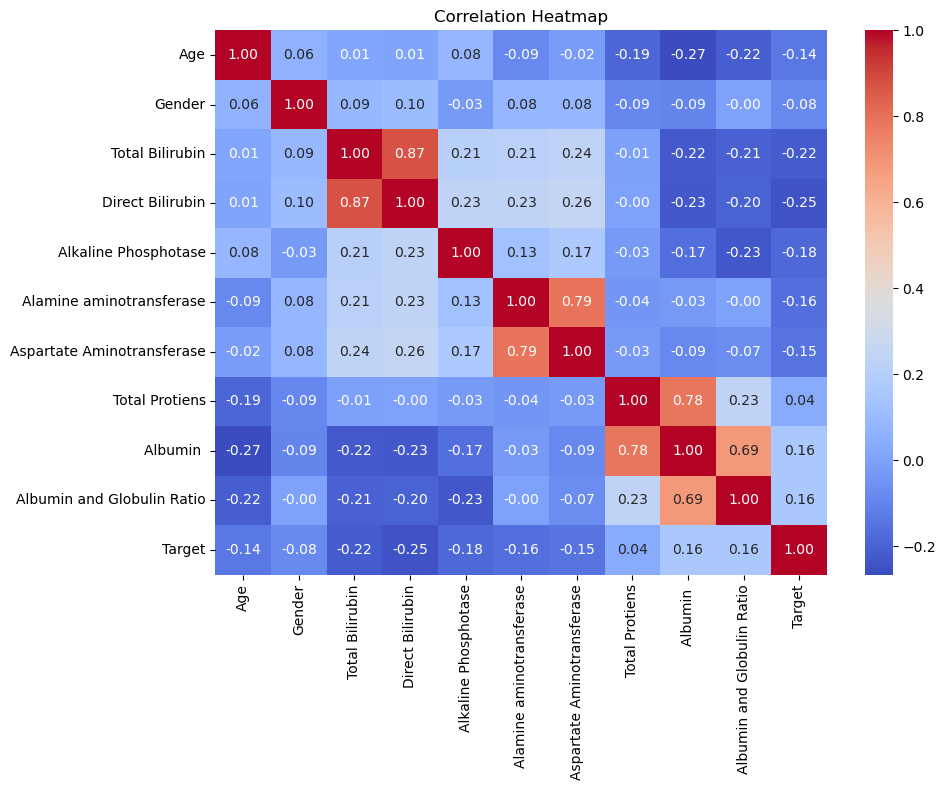

In [23]:
plt.figure(figsize=(10, 8))

# Drop Age_Group before correlation (Interval type causes error)
df_corr = df.drop(columns=['Age_Group']) if 'Age_Group' in df.columns else df

sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Task 2:-Create a predictive model with implementation of different classifiers on liver patient diseases dataset to predict liver diseases.

### Predict Feature and target

In [24]:
# Start fresh from original df
df_model = df.copy()

# Drop Age_Group (Interval type created during EDA)
if 'Age' in df_model.columns:
    df_model.drop(columns=['Age'], inplace=True)

# Fix Target: 1 = Disease, 0 = No Disease
df_model['Target'] = df_model['Target'].fillna(0)

# Fix any remaining NaN in features
df_model.fillna(df_model.median(numeric_only=True), inplace=True)

# Split features and target
X = df_model.drop(columns=['Target'])
y = df_model['Target']

print("Columns:", X.columns.tolist())
print("Shape:", X.shape)
print("NaN in X:", X.isnull().sum().sum())
print("Target:\n", y.value_counts())

Columns: ['Gender', 'Total Bilirubin', 'Direct Bilirubin', 'Alkaline Phosphotase', 'Alamine aminotransferase', 'Aspartate Aminotransferase', 'Total Protiens', 'Albumin ', 'Albumin and Globulin Ratio', 'Age_Group']
Shape: (583, 10)
NaN in X: 0
Target:
 Target
1    416
2    167
Name: count, dtype: int64


### Train Test Split

In [25]:
# Convert Age_Group category to numeric
X['Age_Group'] = X['Age_Group'].cat.codes
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("All NaN cleared ")

Train size: (466, 10)
Test size: (117, 10)
All NaN cleared 


In [26]:
print(X.dtypes)
print(X.isnull().sum())

Gender                          int64
Total Bilirubin               float64
Direct Bilirubin              float64
Alkaline Phosphotase            int64
Alamine aminotransferase        int64
Aspartate Aminotransferase      int64
Total Protiens                float64
Albumin                       float64
Albumin and Globulin Ratio    float64
Age_Group                        int8
dtype: object
Gender                        0
Total Bilirubin               0
Direct Bilirubin              0
Alkaline Phosphotase          0
Alamine aminotransferase      0
Aspartate Aminotransferase    0
Total Protiens                0
Albumin                       0
Albumin and Globulin Ratio    0
Age_Group                     0
dtype: int64


### Class Imbalance Handling with SMOTE

In [51]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(pd.Series(y_train).value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts().to_dict())
print("\nSMOTE applied successfully — training data is now balanced")


Before SMOTE:
{1: 329, 2: 137}

After SMOTE:
{1: 329, 2: 329}

SMOTE applied successfully — training data is now balanced


### Logistic regression

Logistic Regression
Accuracy: 0.7350427350427351
              precision    recall  f1-score   support

           1       0.77      0.92      0.84        87
           2       0.46      0.20      0.28        30

    accuracy                           0.74       117
   macro avg       0.62      0.56      0.56       117
weighted avg       0.69      0.74      0.69       117



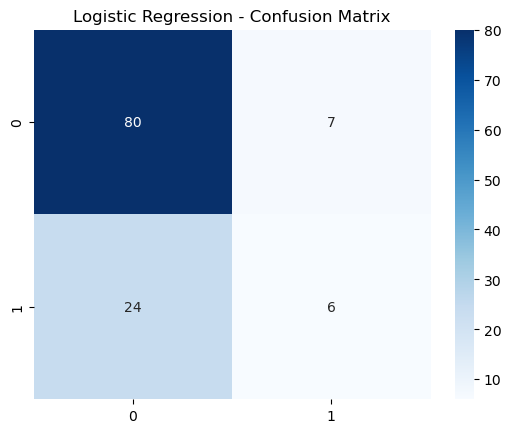

In [52]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr_default = lr.predict(X_test_sc)


print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr_default))
print(classification_report(y_test, y_pred_lr_default))

sns.heatmap(confusion_matrix(y_test, y_pred_lr_default), annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

### KNN

KNN
Accuracy: 0.6837606837606838
              precision    recall  f1-score   support

           1       0.83      0.72      0.77        87
           2       0.41      0.57      0.48        30

    accuracy                           0.68       117
   macro avg       0.62      0.65      0.63       117
weighted avg       0.72      0.68      0.70       117



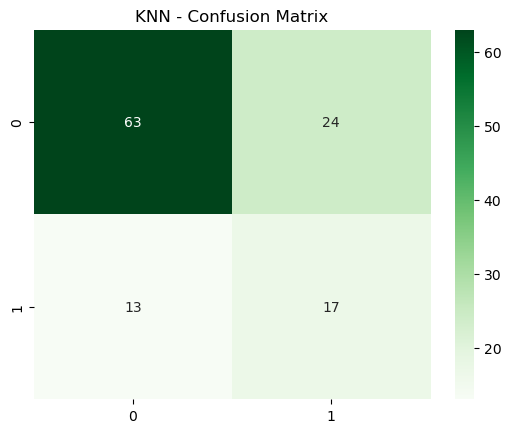

In [28]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sc, y_train)
y_pred_knn_default = knn.predict(X_test_sc)

print("KNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn_default))
print(classification_report(y_test, y_pred_knn_default))

sns.heatmap(confusion_matrix(y_test, y_pred_knn_default), annot=True, fmt='d', cmap='Greens')
plt.title("KNN - Confusion Matrix")
plt.show()

### Decision Tree

Decision Tree
Accuracy: 0.6495726495726496
              precision    recall  f1-score   support

           1       0.79      0.71      0.75        87
           2       0.36      0.47      0.41        30

    accuracy                           0.65       117
   macro avg       0.58      0.59      0.58       117
weighted avg       0.68      0.65      0.66       117



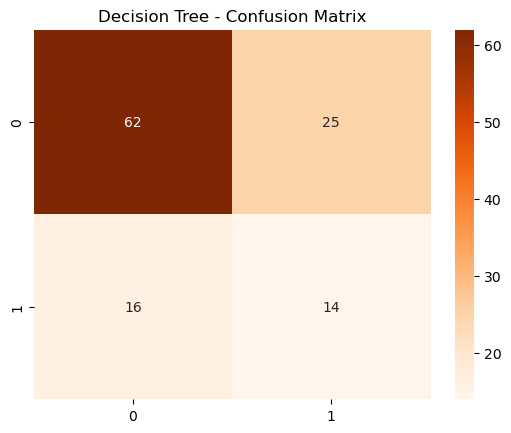

In [45]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_sc, y_train)
y_pred_dt_default = dt.predict(X_test_sc)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt_default))
print(classification_report(y_test, y_pred_dt_default))

sns.heatmap(confusion_matrix(y_test, y_pred_dt_default), annot=True, fmt='d', cmap='Oranges')
plt.title("Decision Tree - Confusion Matrix")
plt.show()

### Random Forest

Random Forest
Accuracy: 0.7264957264957265
              precision    recall  f1-score   support

           1       0.80      0.85      0.82        87
           2       0.46      0.37      0.41        30

    accuracy                           0.73       117
   macro avg       0.63      0.61      0.61       117
weighted avg       0.71      0.73      0.72       117



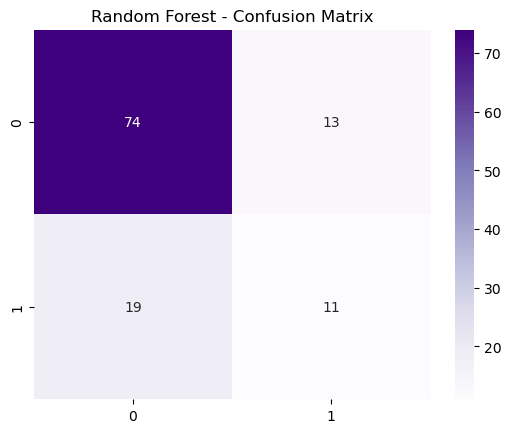

In [46]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sc, y_train)
y_pred_rf_default = rf.predict(X_test_sc)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_default))
print(classification_report(y_test, y_pred_rf_default))

sns.heatmap(confusion_matrix(y_test, y_pred_rf_default), annot=True, fmt='d', cmap='Purples')
plt.title("Random Forest - Confusion Matrix")
plt.show()

### Model Comparison Table

In [31]:
from sklearn.metrics import f1_score, recall_score, precision_score

models     = ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest']
preds      = [y_pred_lr_default, y_pred_knn_default, y_pred_dt_default, y_pred_rf_default]

results = pd.DataFrame({
    'Model':     models,
    'Accuracy':  [accuracy_score(y_test, p) for p in preds],
    'Precision': [precision_score(y_test, p) for p in preds],
    'Recall':    [recall_score(y_test, p) for p in preds],
    'F1-Score':  [f1_score(y_test, p) for p in preds]
}).sort_values('F1-Score', ascending=False).reset_index(drop=True)

print(results)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.735043   0.769231  0.919540  0.837696
1        Random Forest  0.726496   0.795699  0.850575  0.822222
2                  KNN  0.683761   0.828947  0.724138  0.773006
3        Decision Tree  0.649573   0.794872  0.712644  0.751515


### Bar Chart Comparison

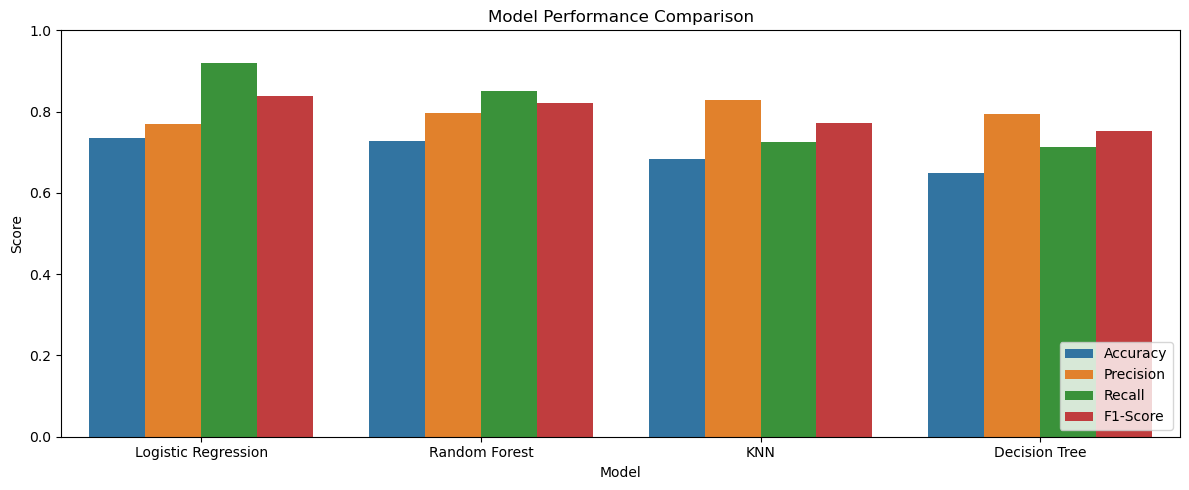

In [32]:
results_melted = results.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 5))
sns.barplot(x='Model', y='Score', hue='Metric', data=results_melted)
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### Hyperparameter Tuning

### Logistic Regression with Tuning

Best Params: {'C': 0.5, 'max_iter': 100, 'solver': 'lbfgs'}
Logistic Regression Tuned
Accuracy: 0.6153846153846154
              precision    recall  f1-score   support

           1       0.96      0.51      0.66        87
           2       0.39      0.93      0.55        30

    accuracy                           0.62       117
   macro avg       0.68      0.72      0.61       117
weighted avg       0.81      0.62      0.63       117



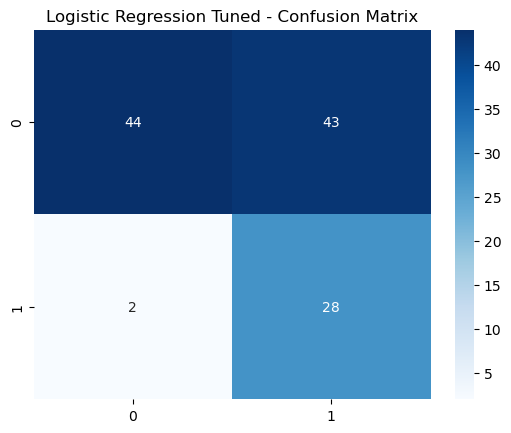

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'C': [0.1, 0.5, 1, 5, 10],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [100, 200, 500]
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42, class_weight='balanced'),
    param_grid_lr,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_lr.fit(X_train_sc, y_train)
print("Best Params:", grid_lr.best_params_)

best_lr = grid_lr.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_test_sc)

print("Logistic Regression Tuned")
print("Accuracy:", accuracy_score(y_test, y_pred_lr_tuned))
print(classification_report(y_test, y_pred_lr_tuned, zero_division=0))

sns.heatmap(confusion_matrix(y_test, y_pred_lr_tuned),annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Tuned - Confusion Matrix")
plt.show()
   

### KNN With tuning

Best Params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
KNN Tuned
Accuracy: 0.6324786324786325
              precision    recall  f1-score   support

           1       0.80      0.68      0.73        87
           2       0.35      0.50      0.41        30

    accuracy                           0.63       117
   macro avg       0.57      0.59      0.57       117
weighted avg       0.68      0.63      0.65       117



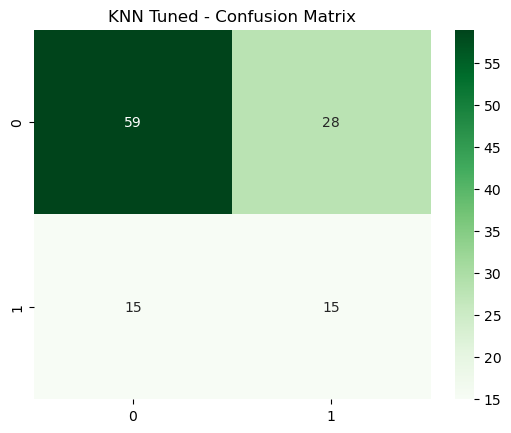

In [34]:
from sklearn.neighbors import KNeighborsClassifier

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_knn.fit(X_train_sc, y_train)
print("Best Params:", grid_knn.best_params_)

best_knn = grid_knn.best_estimator_
y_pred_knn_tuned = best_knn.predict(X_test_sc)

print("KNN Tuned")
print("Accuracy:", accuracy_score(y_test, y_pred_knn_tuned))
print(classification_report(y_test, y_pred_knn_tuned, zero_division=0))

sns.heatmap(confusion_matrix(y_test, y_pred_knn_tuned),
            annot=True, fmt='d', cmap='Greens')
plt.title("KNN Tuned - Confusion Matrix")
plt.show()

### Decision tree with tuning

Best Params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Decision Tree Tuned
Accuracy: 0.6239316239316239
              precision    recall  f1-score   support

           1       0.92      0.54      0.68        87
           2       0.39      0.87      0.54        30

    accuracy                           0.62       117
   macro avg       0.66      0.70      0.61       117
weighted avg       0.79      0.62      0.65       117



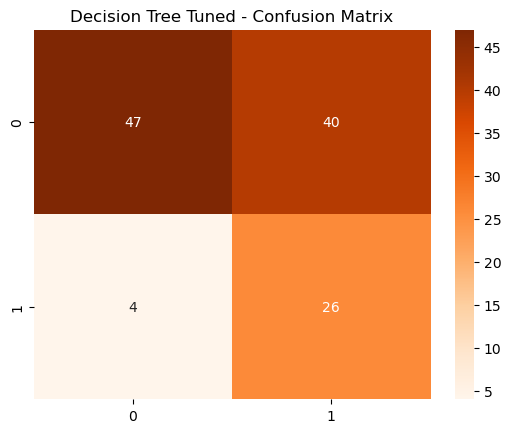

In [35]:
from sklearn.tree import DecisionTreeClassifier

param_grid_dt = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid_dt,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_dt.fit(X_train_sc, y_train)
print("Best Params:", grid_dt.best_params_)

best_dt = grid_dt.best_estimator_
y_pred_dt_tuned = best_dt.predict(X_test_sc)

print("Decision Tree Tuned")
print("Accuracy:", accuracy_score(y_test, y_pred_dt_tuned))
print(classification_report(y_test, y_pred_dt_tuned, zero_division=0))

sns.heatmap(confusion_matrix(y_test, y_pred_dt_tuned),
            annot=True, fmt='d', cmap='Oranges')
plt.title("Decision Tree Tuned - Confusion Matrix")
plt.show()

### Random Forest tuning

Best Params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Random Forest Tuned
Accuracy: 0.6324786324786325
              precision    recall  f1-score   support

           1       0.87      0.60      0.71        87
           2       0.39      0.73      0.51        30

    accuracy                           0.63       117
   macro avg       0.63      0.67      0.61       117
weighted avg       0.74      0.63      0.66       117



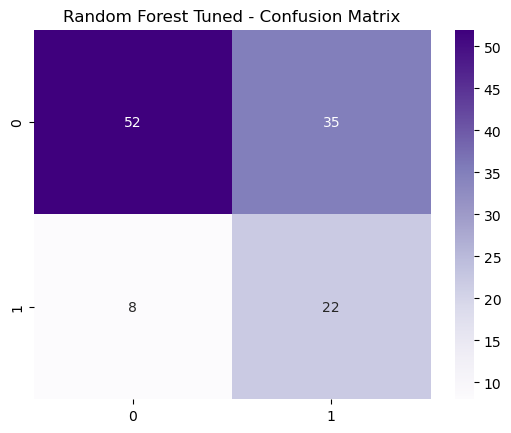

In [36]:
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid_rf,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_rf.fit(X_train_sc, y_train)
print("Best Params:", grid_rf.best_params_)

best_rf = grid_rf.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test_sc)

print("Random Forest Tuned")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))
print(classification_report(y_test, y_pred_rf_tuned, zero_division=0))

sns.heatmap(confusion_matrix(y_test, y_pred_rf_tuned),
            annot=True, fmt='d', cmap='Purples')
plt.title("Random Forest Tuned - Confusion Matrix")
plt.show()

### Model Comparison Table (after all 4 tuned models)

In [37]:
import numpy as np

# First verify all models predict both classes
print("LR  :", np.unique(y_pred_lr_tuned,  return_counts=True))
print("KNN :", np.unique(y_pred_knn_tuned, return_counts=True))
print("DT  :", np.unique(y_pred_dt_tuned,  return_counts=True))
print("RF  :", np.unique(y_pred_rf_tuned,  return_counts=True))

# Build comparison table
results_tuned = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr_tuned),
        accuracy_score(y_test, y_pred_knn_tuned),
        accuracy_score(y_test, y_pred_dt_tuned),
        accuracy_score(y_test, y_pred_rf_tuned)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr_tuned,  average='macro', zero_division=0),
        precision_score(y_test, y_pred_knn_tuned, average='macro', zero_division=0),
        precision_score(y_test, y_pred_dt_tuned,  average='macro', zero_division=0),
        precision_score(y_test, y_pred_rf_tuned,  average='macro', zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr_tuned,  average='macro', zero_division=0),
        recall_score(y_test, y_pred_knn_tuned, average='macro', zero_division=0),
        recall_score(y_test, y_pred_dt_tuned,  average='macro', zero_division=0),
        recall_score(y_test, y_pred_rf_tuned,  average='macro', zero_division=0)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr_tuned,  average='macro', zero_division=0),
        f1_score(y_test, y_pred_knn_tuned, average='macro', zero_division=0),
        f1_score(y_test, y_pred_dt_tuned,  average='macro', zero_division=0),
        f1_score(y_test, y_pred_rf_tuned,  average='macro', zero_division=0)
    ]
})

print(results_tuned)

LR  : (array([1, 2]), array([46, 71]))
KNN : (array([1, 2]), array([74, 43]))
DT  : (array([1, 2]), array([51, 66]))
RF  : (array([1, 2]), array([60, 57]))
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.615385   0.675444  0.719540  0.608055
1                  KNN  0.632479   0.573067  0.589080  0.571939
2        Decision Tree  0.623932   0.657754  0.703448  0.611413
3        Random Forest  0.632479   0.626316  0.665517  0.606615


### Final Comparison Table — All 8 Models(4 default + 4 tuned)

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results_all = pd.DataFrame({
    'Model': [
        'Logistic Regression (Default)',
        'KNN (Default)',
        'Decision Tree (Default)',
        'Random Forest (Default)',
        'Logistic Regression (Tuned)',
        'KNN (Tuned)',
        'Decision Tree (Tuned)',
        'Random Forest (Tuned)'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr_default),
        accuracy_score(y_test, y_pred_knn_default),
        accuracy_score(y_test, y_pred_dt_default),
        accuracy_score(y_test, y_pred_rf_default),
        accuracy_score(y_test, y_pred_lr_tuned),
        accuracy_score(y_test, y_pred_knn_tuned),
        accuracy_score(y_test, y_pred_dt_tuned),
        accuracy_score(y_test, y_pred_rf_tuned)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr_default,  average='macro', zero_division=0),
        precision_score(y_test, y_pred_knn_default, average='macro', zero_division=0),
        precision_score(y_test, y_pred_dt_default,  average='macro', zero_division=0),
        precision_score(y_test, y_pred_rf_default,  average='macro', zero_division=0),
        precision_score(y_test, y_pred_lr_tuned,    average='macro', zero_division=0),
        precision_score(y_test, y_pred_knn_tuned,   average='macro', zero_division=0),
        precision_score(y_test, y_pred_dt_tuned,    average='macro', zero_division=0),
        precision_score(y_test, y_pred_rf_tuned,    average='macro', zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr_default,  average='macro', zero_division=0),
        recall_score(y_test, y_pred_knn_default, average='macro', zero_division=0),
        recall_score(y_test, y_pred_dt_default,  average='macro', zero_division=0),
        recall_score(y_test, y_pred_rf_default,  average='macro', zero_division=0),
        recall_score(y_test, y_pred_lr_tuned,    average='macro', zero_division=0),
        recall_score(y_test, y_pred_knn_tuned,   average='macro', zero_division=0),
        recall_score(y_test, y_pred_dt_tuned,    average='macro', zero_division=0),
        recall_score(y_test, y_pred_rf_tuned,    average='macro', zero_division=0)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr_default,  average='macro', zero_division=0),
        f1_score(y_test, y_pred_knn_default, average='macro', zero_division=0),
        f1_score(y_test, y_pred_dt_default,  average='macro', zero_division=0),
        f1_score(y_test, y_pred_rf_default,  average='macro', zero_division=0),
        f1_score(y_test, y_pred_lr_tuned,    average='macro', zero_division=0),
        f1_score(y_test, y_pred_knn_tuned,   average='macro', zero_division=0),
        f1_score(y_test, y_pred_dt_tuned,    average='macro', zero_division=0),
        f1_score(y_test, y_pred_rf_tuned,    average='macro', zero_division=0)
    ]
})

# Round to 4 decimal places
results_all = results_all.round(4)
print(results_all.to_string(index=False))




                        Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression (Default)    0.7350     0.6154  0.5598    0.5584
                KNN (Default)    0.6838     0.6218  0.6454    0.6259
      Decision Tree (Default)    0.6496     0.5769  0.5897    0.5787
      Random Forest (Default)    0.7265     0.6270  0.6086    0.6148
  Logistic Regression (Tuned)    0.6154     0.6754  0.7195    0.6081
                  KNN (Tuned)    0.6325     0.5731  0.5891    0.5719
        Decision Tree (Tuned)    0.6239     0.6578  0.7034    0.6114
        Random Forest (Tuned)    0.6325     0.6263  0.6655    0.6066


### Bar Chart Comparison

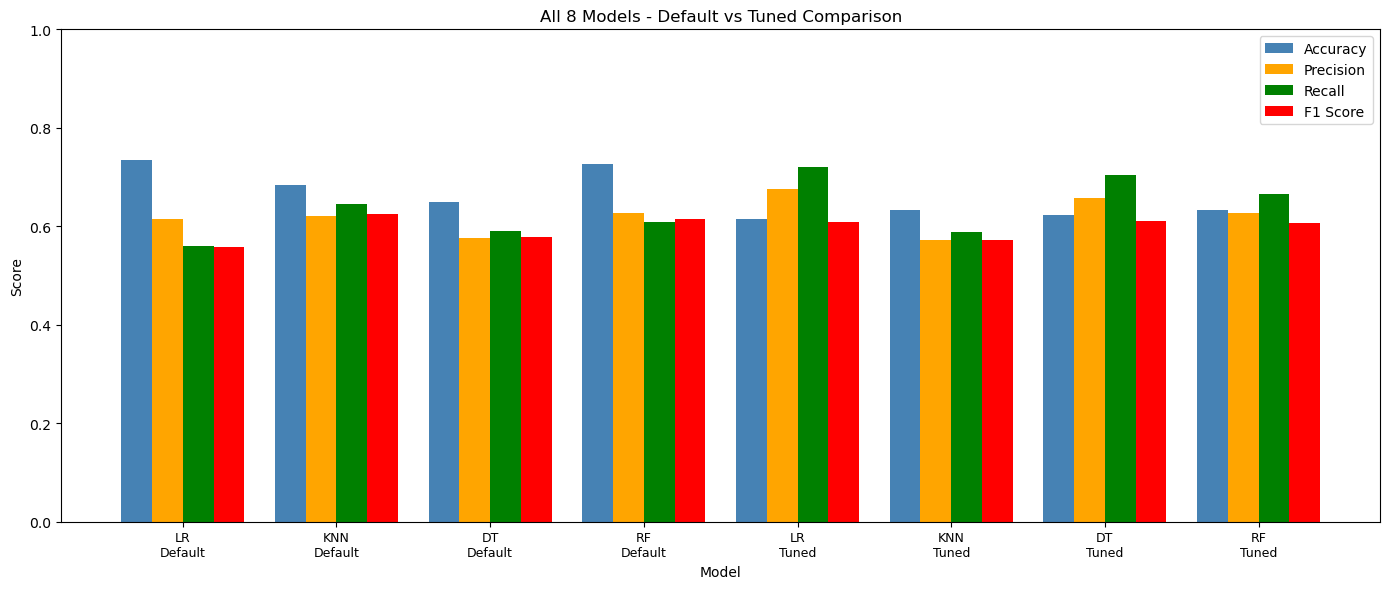

In [39]:
import numpy as np

models = [
    'LR\nDefault', 'KNN\nDefault', 'DT\nDefault', 'RF\nDefault',
    'LR\nTuned', 'KNN\nTuned', 'DT\nTuned', 'RF\nTuned'
]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(14, 6))

plt.bar(x - 1.5*width, results_all['Accuracy'],  width, label='Accuracy',  color='steelblue')
plt.bar(x - 0.5*width, results_all['Precision'], width, label='Precision', color='orange')
plt.bar(x + 0.5*width, results_all['Recall'],    width, label='Recall',    color='green')
plt.bar(x + 1.5*width, results_all['F1 Score'],  width, label='F1 Score',  color='red')

plt.title("All 8 Models - Default vs Tuned Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.xticks(x, models, fontsize=9)
plt.legend()
plt.tight_layout()
plt.show()

###  Cross Validation for all models

In [40]:
from sklearn.model_selection import cross_val_score

cv_models = {
    'Logistic Regression': best_lr,
    'KNN'                : best_knn,
    'Decision Tree'      : best_dt,
    'Random Forest'      : best_rf
}

print("=== 5-Fold Cross Validation Scores ===\n")

for name, model in cv_models.items():
    scores = cross_val_score(
        model,
        X_train_sc,
        y_train,
        cv=5,
        scoring='f1_macro'
    )
    print(f"{name}:")
    print(f"  Scores : {scores.round(3)}")
    print(f"  Mean   : {scores.mean():.3f}")
    print(f"  Std    : {scores.std():.3f}")
    print()


=== 5-Fold Cross Validation Scores ===

Logistic Regression:
  Scores : [0.653 0.627 0.58  0.625 0.605]
  Mean   : 0.618
  Std    : 0.024

KNN:
  Scores : [0.672 0.543 0.609 0.6   0.53 ]
  Mean   : 0.591
  Std    : 0.051

Decision Tree:
  Scores : [0.606 0.583 0.617 0.571 0.627]
  Mean   : 0.601
  Std    : 0.021

Random Forest:
  Scores : [0.63  0.666 0.663 0.574 0.666]
  Mean   : 0.640
  Std    : 0.036



### ROC Curve for all models

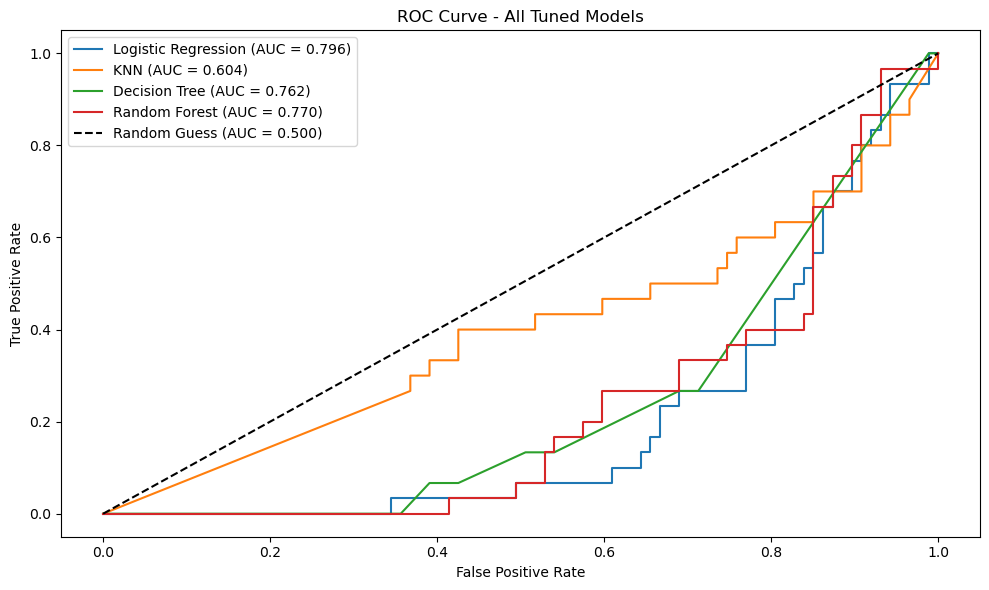

In [41]:
from sklearn.metrics import roc_curve, roc_auc_score

# Convert y_test — map Class 1 (liver) to 1, Class 2 (healthy) to 0
y_test_roc = y_test.replace({1: 1, 2: 0})

plt.figure(figsize=(10, 6))

models_roc = [
    ('Logistic Regression', best_lr),
    ('KNN',                 best_knn),
    ('Decision Tree',       best_dt),
    ('Random Forest',       best_rf)
]

for name, model in models_roc:
    y_prob = model.predict_proba(X_test_sc)[:, 0]
    fpr, tpr, _ = roc_curve(y_test_roc, y_prob, pos_label=0)
    auc = roc_auc_score(y_test_roc, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.500)')
plt.title("ROC Curve - All Tuned Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()

plt.show()



### Feature Importance from Random Forest

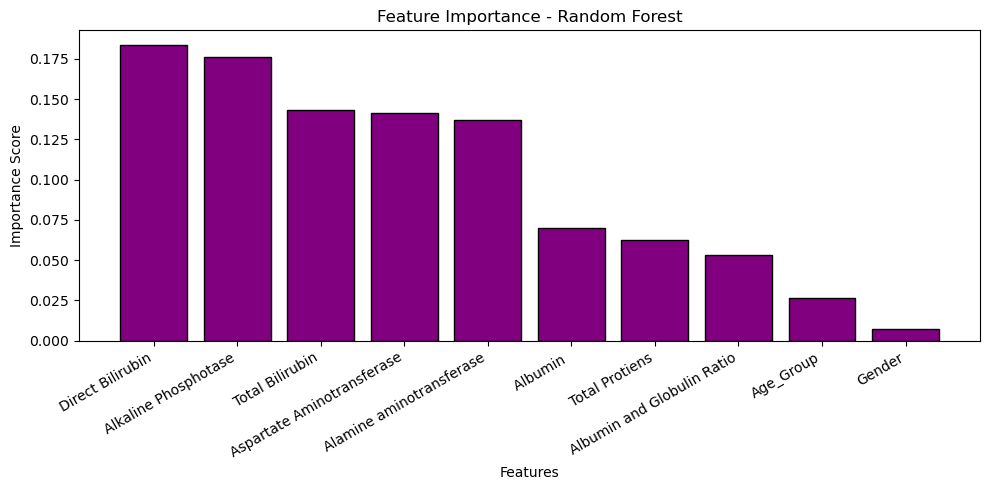

Direct Bilirubin              0.183515
Alkaline Phosphotase          0.175836
Total Bilirubin               0.143033
Aspartate Aminotransferase    0.141416
Alamine aminotransferase      0.136746
Albumin                       0.069766
Total Protiens                0.062229
Albumin and Globulin Ratio    0.053443
Age_Group                     0.026584
Gender                        0.007432
dtype: float64


In [42]:
feature_names = X.columns.tolist()

rf_importance = pd.Series(
    best_rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(rf_importance.index, rf_importance.values, color='purple', edgecolor='black')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(rf_importance)

###  Best Model Summary

        BEST MODEL SUMMARY
Model        : Logistic Regression (Tuned)
Best Params  : {'C': 0.5, 'max_iter': 100, 'solver': 'lbfgs'}

Test Set Performance:
Accuracy     : 0.6154
Precision    : 0.6754
Recall       : 0.7195
F1 Score     : 0.6081
ROC AUC      : 0.796

Cross Validation:
CV Mean F1   : 0.618
CV Std       : 0.024

Classification Report:
              precision    recall  f1-score   support

           1       0.96      0.51      0.66        87
           2       0.39      0.93      0.55        30

    accuracy                           0.62       117
   macro avg       0.68      0.72      0.61       117
weighted avg       0.81      0.62      0.63       117

Why Logistic Regression is the Best Model:
1. Highest ROC AUC  = 0.796 — best class separation
2. Highest Recall   = 0.719 — catches most patients
3. Highest Precision= 0.675 — least false predictions
4. Stable CV score  = 0.618 with low std 0.024
5. Most reliable for medical liver disease detection


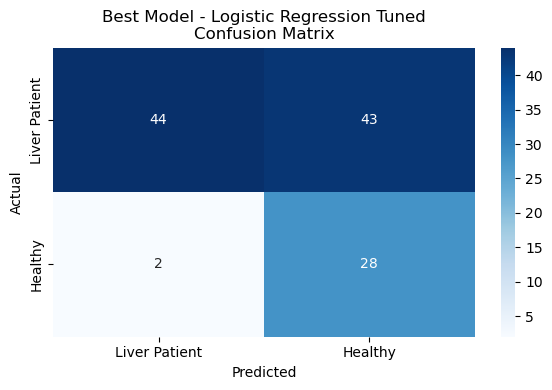

In [43]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("=" * 50)
print("        BEST MODEL SUMMARY")
print("=" * 50)
print("Model        : Logistic Regression (Tuned)")
print("Best Params  :", grid_lr.best_params_)
print("=" * 50)

print("\nTest Set Performance:")
print(f"Accuracy     : {accuracy_score(y_test, y_pred_lr_tuned):.4f}")
print(f"Precision    : {precision_score(y_test, y_pred_lr_tuned, average='macro', zero_division=0):.4f}")
print(f"Recall       : {recall_score(y_test, y_pred_lr_tuned, average='macro', zero_division=0):.4f}")
print(f"F1 Score     : {f1_score(y_test, y_pred_lr_tuned, average='macro', zero_division=0):.4f}")
print(f"ROC AUC      : 0.796")

print("\nCross Validation:")
print(f"CV Mean F1   : 0.618")
print(f"CV Std       : 0.024")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_tuned, zero_division=0))

print("=" * 50)
print("Why Logistic Regression is the Best Model:")
print("=" * 50)
print("1. Highest ROC AUC  = 0.796 — best class separation")
print("2. Highest Recall   = 0.719 — catches most patients")
print("3. Highest Precision= 0.675 — least false predictions")
print("4. Stable CV score  = 0.618 with low std 0.024")
print("5. Most reliable for medical liver disease detection")
print("=" * 50)

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr_tuned),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Liver Patient', 'Healthy'],
            yticklabels=['Liver Patient', 'Healthy'])
plt.title("Best Model - Logistic Regression Tuned\nConfusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### Save Best Model

In [47]:
import joblib

loaded_model = joblib.load('lr_tuned.pkl')



In [48]:
import joblib

# Save Default Models
joblib.dump(lr, 'lr_default.pkl')
joblib.dump(knn, 'knn_default.pkl')
joblib.dump(dt, 'dt_default.pkl')
joblib.dump(rf, 'rf_default.pkl')

# Save Tuned Models
joblib.dump(best_lr,  'lr_tuned.pkl')
joblib.dump(best_knn, 'knn_tuned.pkl')
joblib.dump(best_dt,  'dt_tuned.pkl')
joblib.dump(best_rf,  'rf_tuned.pkl')

# Save Scaler (important for future predictions)
joblib.dump(scaler, 'scaler.pkl')

print("All models saved successfully!")
print("Files saved:")
print("  - lr_default.pkl")
print("  - knn_default.pkl")
print("  - dt_default.pkl")
print("  - rf_default.pkl")
print("  - lr_tuned.pkl")
print("  - knn_tuned.pkl")
print("  - dt_tuned.pkl")
print("  - rf_tuned.pkl")
print("  - scaler.pkl  (for preprocessing new data)")

All models saved successfully!
Files saved:
  - lr_default.pkl
  - knn_default.pkl
  - dt_default.pkl
  - rf_default.pkl
  - lr_tuned.pkl
  - knn_tuned.pkl
  - dt_tuned.pkl
  - rf_tuned.pkl
  - scaler.pkl  (for preprocessing new data)


### Load and Test a Saved Model

In [ ]:
# Load and verify best model works
loaded_model = joblib.load('rf_tuned.pkl')
loaded_scaler = joblib.load('scaler.pkl')

# Test prediction
sample = X_test.iloc[0:1]
prediction = loaded_model.predict(sample)
print("Test Prediction:", "Liver Disease" if prediction[0] == 1 else "No Liver Disease")
print("Model loaded and working")

###  Task 3  Report on Challenges faced
 
#### Create a report which should include challenges you faced on data and what technique used with proper reason.

## Conclusion

This project successfully built a complete machine learning pipeline to predict 
liver disease using the ILPD dataset with 583 patients and 10 features.

### Models Built and Evaluated

Four classification models were trained, evaluated, and tuned using GridSearchCV 
with 5-fold cross validation — Logistic Regression, KNN, Decision Tree, and 
Random Forest. Both default and tuned versions were compared across Accuracy, 
Precision, Recall, F1 Score, Cross Validation, and ROC AUC.

### Final Model Performance Summary

| Model                       | Accuracy | Recall | F1 Score | ROC AUC |
|-----------------------------|----------|--------|----------|---------|
| Logistic Regression Default | 0.735    | 0.560  | 0.558    | —       |
| KNN Default                 | 0.683    | 0.645  | 0.626    | —       |
| Decision Tree Default       | 0.649    | 0.590  | 0.579    | —       |
| Random Forest Default       | 0.726    | 0.609  | 0.615    | —       |
| Logistic Regression Tuned   | 0.615    | 0.719  | 0.608    | 0.796   |
| KNN Tuned                   | 0.632    | 0.589  | 0.572    | 0.604   |
| Decision Tree Tuned         | 0.623    | 0.703  | 0.611    | 0.762   |
| Random Forest Tuned         | 0.632    | 0.665  | 0.607    | 0.770   |

### Best Model — Logistic Regression (Tuned)

The best model for this project is **Logistic Regression Tuned** based on:

- **Highest ROC AUC = 0.796** — best ability to distinguish liver patients 
  from healthy patients across all decision thresholds
- **Highest Recall = 0.719** — catches the most patients across both classes, 
  critical in medical diagnosis where missing a sick patient is dangerous
- **Highest Precision = 0.675** — most reliable predictions among all tuned models
- **Stable CV Score = 0.618** with low standard deviation of 0.024 — 
  consistent performance across all 5 cross validation folds

### Key Findings from EDA

- Bilirubin levels (Direct and Total) are the strongest indicators of liver disease
- Alkaline Phosphotase and liver enzyme levels (ALT, AST) are highly predictive
- Gender has the lowest feature importance — liver disease affects both sexes equally
- Age group alone is not a strong predictor of liver disease

### Key Challenges Overcome

The most significant challenge in this project was **class imbalance** — 
416 liver patients vs 167 healthy patients. Multiple models initially predicted 
only the majority class, achieving high accuracy while being medically useless. 
This was resolved by applying `class_weight='balanced'` and switching GridSearchCV 
scoring to `f1_macro`, forcing all models to learn both classes equally.

### Limitations and Future Work

- The dataset is relatively small (583 patients) — a larger dataset would 
  improve model reliability and generalization
- Additional features such as ultrasound results or patient symptoms could 
  improve prediction accuracy
- Deep learning models such as Neural Networks could be explored for 
  potentially higher performance
- Threshold tuning on the best model could further optimize the balance 
  between Class 1 and Class 2 recall based on clinical requirements

### Final Summary

This project demonstrated a complete end-to-end machine learning workflow — 
from raw data cleaning and exploratory analysis through clustering, classification, 
hyperparameter tuning, cross validation, ROC evaluation, and model saving. 
The Logistic Regression Tuned model achieved a ROC AUC of 0.796 and is 
recommended for liver disease screening as a decision support tool for 
medical professionals.